# Aviation Load Factor Analysis for Seasonal Demand, Covid Recovery, Cargo Shift leading up to Covid 

## Data Processing and ETL operations for converting raw DGCA data files 
Link - https://www.dgca.gov.in/digigov-portal/?baseLocale=en_US?page=259/4184/servicename

In [9]:
import pandas as pd
import os
import glob

# Standardized Column Mapping
COL_INDICES = [1, 2, 3, 4, 5, 6, 7, 15, 16]
COL_NAMES = ['Departures', 'Hours', 'Kilometers', 'Passengers_Carried', 'RPK', 'ASK', 'PLF', 'ATK', 'WLF']
MONTHS_LIST = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JULY', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

def get_data_slice(df, start_month, num_months, offset=0):
    """
    Finds the row containing start_month and extracts the requested number of months.
    """
    # Find the row index where the first column matches the start_month
    try:
        start_idx = df[df.iloc[:, 0].astype(str).str.strip().str.upper() == start_month].index[offset]
        data = df.iloc[start_idx : start_idx + num_months, COL_INDICES].copy()
        return data
    except Exception:
        return None

def get_fy_months(session_str):
    s_yr, e_yr = session_str.split('-')[0][-2:], session_str.split('-')[1][-2:]
    return ([f"{str(m).zfill(2)}/{s_yr}" for m in range(4, 13)] + 
            [f"{str(m).zfill(2)}/{e_yr}" for m in range(1, 4)])

def process_regular_fy_file(filepath):
    fname = os.path.basename(filepath)
    session, airline, code = fname.replace('.xlsx', '').split('_')
    df = pd.read_excel(filepath, header=None)
    
    # Regular files usually start with April (APR)
    data_slice = get_data_slice(df, 'APR', 12)
    if data_slice is not None:
        data_slice.columns = COL_NAMES
        data_slice.insert(0, 'Date', get_fy_months(session))
        data_slice['Airline'], data_slice['Type'], data_slice['Session'] = airline, code, session
        data_slice.to_csv(f"data/processed/{session}_{airline}_{code}.csv", index=False)

def stitch_special_fy(airline, code, raw_dir='data/raw'):
    f21 = os.path.join(raw_dir, f"{airline}_2021-22.xlsx")
    f22 = os.path.join(raw_dir, f"{airline}_2022-23.xlsx")
    
    if not (os.path.exists(f21) and os.path.exists(f22)): return
    
    df21_all = pd.read_excel(f21, header=None)
    df22_all = pd.read_excel(f22, header=None)
    
    # Table offset: Domestic is 1st occurrence (0), International is 2nd (1)
    tbl_idx = 0 if code == '1' else 1
    
    # Part 1: APR-DEC 2021 from the 21-22 Calendar file
    apr_dec = get_data_slice(df21_all, 'APR', 9, offset=tbl_idx)
    
    # Part 2: JAN-MAR 2022 from the 22-23 Calendar file
    jan_mar = get_data_slice(df22_all, 'JAN', 3, offset=tbl_idx)
    
    if apr_dec is not None and jan_mar is not None:
        apr_dec.columns = COL_NAMES
        jan_mar.columns = COL_NAMES
        apr_dec.insert(0, 'Date', [f"{str(m).zfill(2)}/21" for m in range(4, 13)])
        jan_mar.insert(0, 'Date', [f"{str(m).zfill(2)}/22" for m in range(1, 4)])
        
        combined = pd.concat([apr_dec, jan_mar])
        combined['Airline'], combined['Type'], combined['Session'] = airline, code, '2021-22'
        combined.to_csv(f"data/processed/2021-22_{airline}_{code}.csv", index=False)

def run_master_pipeline():
    # 1. Process Regular FY Files
    for f in glob.glob("data/raw/*.xlsx"):
        if os.path.basename(f)[0].isdigit():
            process_regular_fy_file(f)
            
    # 2. Process Stitching
    special_files = [b for b in os.listdir("data/raw") if b.endswith(".xlsx") and not b[0].isdigit()]
    airlines = set([b.split('_')[0] for b in special_files])
    for air in airlines:
        for code in ['1', '2']:
            stitch_special_fy(air, code)
    print("✅ High-Quality Dataset generated with dynamic row detection.")

In [15]:
# The absolute index where the first month (APR or JAN) starts
STRICT_START_ROW = 5 

def process_regular_fy_file(filepath):
    """Handles: 2018-19_AI_1.xlsx starting from Row 6 (Index 5)"""
    fname = os.path.basename(filepath)
    try:
        parts = fname.replace('.xlsx', '').split('_')
        session, airline, code = parts[0], parts[1], parts[2]
        
        df = pd.read_excel(filepath, header=None)
        
        # We grab 12 months starting from Row 6 (Index 5)
        data_slice = df.iloc[STRICT_START_ROW : STRICT_START_ROW + 12, COL_INDICES].copy()
        
        data_slice.columns = COL_NAMES
        data_slice.insert(0, 'Date', get_fy_months(session))
        data_slice['Airline'], data_slice['Type'], data_slice['Session'] = airline, code, session
        
        out_path = os.path.join('data/processed', f"{session}_{airline}_{code}_master.csv")
        data_slice.to_csv(out_path, index=False)
        return True
    except Exception as e:
        print(f"❌ Error in {fname}: {e}")
        return False

def stitch_special_fy(airline, code, raw_dir='data/raw'):
    """Stitches Apr-Dec 21 and Jan-Mar 22 from special Calendar Year files."""
    f21 = os.path.join(raw_dir, f"{airline}_2021-22.xlsx")
    f22 = os.path.join(raw_dir, f"{airline}_2022-23.xlsx")
    
    if not (os.path.exists(f21) and os.path.exists(f22)): return False

    df21_all = pd.read_excel(f21, header=None)
    df22_all = pd.read_excel(f22, header=None)
    
    # Logic for stacked tables: Domestic is top, International is usually ~25 rows down
    offset = 0 if code == '1' else 25 
    
    # 2021-22 File: JAN is Index 5, so APR (4th month) is Index 8
    apr_dec = df21_all.iloc[STRICT_START_ROW + 3 + offset : STRICT_START_ROW + 12 + offset, COL_INDICES].copy()
    apr_dec.columns = COL_NAMES
    apr_dec.insert(0, 'Date', [f"{str(m).zfill(2)}/21" for m in range(4, 13)])
    
    # 2022-23 File: JAN is Index 5, FEB is 6, MAR is 7
    jan_mar = df22_all.iloc[STRICT_START_ROW + offset : STRICT_START_ROW + 3 + offset, COL_INDICES].copy()
    jan_mar.columns = COL_NAMES
    jan_mar.insert(0, 'Date', [f"{str(m).zfill(2)}/22" for m in range(1, 4)])
    
    combined = pd.concat([apr_dec, jan_mar])
    combined['Airline'], combined['Type'], combined['Session'] = airline, code, '2021-22'
    
    out_path = os.path.join('data/processed', f"2021-22_{airline}_{code}_master.csv")
    combined.to_csv(out_path, index=False)
    return True

In [16]:
run_master_pipeline()


--- Starting Pipeline ---

✅ Pipeline Complete.
Regular Files Saved: 90
Stitched Files Saved: 16
Total Files in data/processed: 104


## Creating Global DF from processed files to filter later

In [18]:
def load_and_combine_data(directory):
    all_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    temp_list = []

    for file in all_files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        temp_list.append(df)

    return pd.concat(temp_list, ignore_index=True)

In [19]:
processed_dir = 'data/processed/'
global_df = load_and_combine_data(processed_dir)

In [20]:
global_df.head(3)

,Date,Departures,Hours,Kilometers,Passengers_Carried,RPK,ASK,PLF,ATK,WLF,Airline,Type,Session
0,04/24,2976,5348.733333,2768.68,422278,399.775241,486.169165,82.229658,55.3736,29.922991,AIE,1,2024-25
1,05/24,2233,4168.566667,1647.297,328320,328.669004,388.785568,84.537347,44.18614,76.043982,AIE,1,2024-25
2,06/24,2844,5302.066667,2802.503,423233,426.312631,492.057232,86.63883,56.05006,76.982586,AIE,1,2024-25


In [21]:
global_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                1200 non-null   str   
 1   Departures          1121 non-null   object
 2   Hours               1120 non-null   object
 3   Kilometers          1116 non-null   object
 4   Passengers_Carried  1073 non-null   object
 5   RPK                 1114 non-null   object
 6   ASK                 1114 non-null   object
 7   PLF                 1134 non-null   object
 8   ATK                 1125 non-null   object
 9   WLF                 1134 non-null   object
 10  Airline             1200 non-null   str   
 11  Type                1200 non-null   int64 
 12  Session             1200 non-null   str   
dtypes: int64(1), object(9), str(3)
memory usage: 122.0+ KB


In [22]:
numeric_cols = [
    'Departures', 'Hours', 'Kilometers', 'Passengers_Carried',
    'RPK', 'ASK', 'PLF', 'ATK', 'WLF'
]

In [23]:
for col in numeric_cols:
# Remove commas if they exist, then convert to numeric
# Using .astype(str) first ensures we don't crash on existing NaNs
    global_df[col] = pd.to_numeric(global_df[col].astype(str).str.replace(',', ''), errors='coerce')

In [24]:
global_df['Date'] = pd.to_datetime(global_df['Date'], format='%m/%y')

In [26]:
global_df.head()

,Date,Departures,Hours,Kilometers,Passengers_Carried,RPK,ASK,PLF,ATK,WLF,Airline,Type,Session
0,2024-04-01,2976.0,5348.733333,2768.680,422278.0,399.775241,486.169165,82.229658,55.37360,29.922991,AIE,1,2024-25
1,2024-05-01,2233.0,4168.566667,1647.297,328320.0,328.669004,388.785568,84.537347,44.18614,76.043982,AIE,1,2024-25
2,2024-06-01,2844.0,5302.066667,2802.503,423233.0,426.312631,492.057232,86.638830,56.05006,76.982586,AIE,1,2024-25
3,2024-07-01,2283.0,4014.783333,2140.715,317746.0,308.142391,376.319538,81.883176,42.81430,74.974232,AIE,1,2024-25
4,2024-08-01,3094.0,5252.283333,2970.717,408361.0,400.051181,521.013768,76.783226,59.41434,69.576127,AIE,1,2024-25


In [27]:
global_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                1200 non-null   datetime64[us]
 1   Departures          1111 non-null   float64       
 2   Hours               1110 non-null   float64       
 3   Kilometers          1111 non-null   float64       
 4   Passengers_Carried  1068 non-null   float64       
 5   RPK                 1109 non-null   float64       
 6   ASK                 1109 non-null   float64       
 7   PLF                 1093 non-null   float64       
 8   ATK                 1120 non-null   float64       
 9   WLF                 1105 non-null   float64       
 10  Airline             1200 non-null   str           
 11  Type                1200 non-null   int64         
 12  Session             1200 non-null   str           
dtypes: datetime64[us](1), float64(9), int64(1), str(2)
memory u

## Creating Datasets A, B, C through filtering Global DF

In [29]:
# Dataset A: 3-Year Complete Market View (All 8 Airlines)
# Years: 2022-23, 2023-24, 2024-25
years_a = ['2022-23', '2023-24', '2024-25']
dataset_a = global_df[global_df['Session'].isin(years_a)].copy()

# Dataset B: 7-Year Core Recovery Trend (5 Carriers only)
# Carriers: Air India, Air India Express, Alliance Air, Blue Dart, IndiGo
years_b = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
carriers_b = ['AI', 'AIE', 'ALLIANCE', 'BLUE', 'INDIGO']
dataset_b = global_df[(global_df['Session'].isin(years_b)) & (global_df['Airline'].isin(carriers_b))].copy()

# Dataset C: Pre/Mid-COVID Transition (7 Airlines, Excluding Akasa)
# Years: 2018-19, 2019-20, 2020-21
years_c = ['2018-19', '2019-20', '2020-21']
dataset_c = global_df[(global_df['Session'].isin(years_c)) & (global_df['Airline'] != 'AKASA')].copy()

# Verification of filters
print(f"Dataset A: {dataset_a['Airline'].nunique()} airlines across {dataset_a['Session'].nunique()} sessions.")
print(f"Dataset B: {dataset_b['Airline'].nunique()} airlines across {dataset_b['Session'].nunique()} sessions.")
print(f"Dataset C: {dataset_c['Airline'].nunique()} airlines across {dataset_c['Session'].nunique()} sessions.")

Dataset A: 8 airlines across 3 sessions.
Dataset B: 5 airlines across 7 sessions.
Dataset C: 7 airlines across 3 sessions.


In [30]:
# Saving datasets
output_dir = 'data/filtered/'
dataset_a.to_csv(os.path.join(output_dir, 'dataset_a_3yr_market.csv'), index=False)
dataset_b.to_csv(os.path.join(output_dir, 'dataset_b_7yr_recovery.csv'), index=False)
dataset_c.to_csv(os.path.join(output_dir, 'dataset_c_3yr_pre_covid.csv'), index=False)

print("Successfully exported 3 datasets to data/filtered/")

Successfully exported 3 datasets to data/filtered/


### Confirming data validity through cargo dependency check

In [31]:
# Calculate the Cargo Dependency Gap for all datasets
# A positive gap means WLF > PLF (Strong cargo presence)
for df in [dataset_a, dataset_b, dataset_c]:
    df['PLF_WLF_Gap'] = df['WLF'] - df['PLF']

# Quick look at the top cargo-dependent months in Dataset B
print(dataset_b[['Date', 'Airline', 'PLF', 'WLF', 'PLF_WLF_Gap']].sort_values(by='PLF_WLF_Gap', ascending=False).head())

          Date Airline        PLF         WLF  PLF_WLF_Gap
601 2020-05-01     AIE  14.552239   99.171598    84.619359
577 2020-05-01      AI  50.138888  133.779374    83.640486
824 2019-12-01    BLUE   0.000000   79.471845    79.471845
821 2019-09-01    BLUE   0.000000   78.908189    78.908189
652 2020-08-01    BLUE   0.000000   77.416601    77.416601


Observation: in May 2020, Air India compensated for low passenger load by overloading the amount of cargo to greater than normal capacity by 33%

## Aggregating pivot tables for visualisations

In [33]:
# 1. Create a categorical type for months in Financial Year order
fy_months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# 2. Extract Month Name and convert to the categorical type
# This ensures that any sorting/pivoting automatically follows the FY order
dataset_a['Month_Name'] = dataset_a['Date'].dt.strftime('%b')
dataset_a['Month_Name'] = pd.Categorical(dataset_a['Month_Name'], categories=fy_months, ordered=True)

# 3. Create the Pivot Table
# Because Month_Name is now a 'Categorical' type, the columns will automatically 
# arrange themselves in the fy_months order (Apr -> Mar)
plf_pivot = dataset_a.pivot_table(
    values='PLF', 
    index='Airline', 
    columns='Month_Name', 
    aggfunc='mean', # Gives mean value across the 3 years observed in dataset
    observed=False # Ensures all months stay in the table even if data is missing
)

print("Verified PLF Seasonal Pivot Table:")
print(plf_pivot)

Verified PLF Seasonal Pivot Table:
Month_Name        Apr        May        Jun        Jul        Aug        Sep  \
Airline                                                                        
AI          83.000394  84.134732  84.110885  81.979561  82.167909  83.310268   
AIE         71.595375  79.027184  73.280358  78.054451  75.314241  72.806831   
AKASA       46.753001  51.276550  51.466597  48.928118  50.110950  53.778285   
ALLIANCE    64.658640  63.217940  64.339711  64.554643  62.730388  53.955537   
BLUE         0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
INDIGO      82.053530  85.544398  84.546324  81.838796  80.942525  81.250067   
SPICE       87.138424  88.829668  86.684996  85.742572  82.913753  82.240907   
VISTARA     82.670261  84.566230  85.784998  83.644542  84.042980  83.642908   

Month_Name        Oct        Nov        Dec        Jan        Feb        Mar  
Airline                                                                       
AI    

In [34]:
# 1. Aggregate PLF and WLF by Airline and Session (Yearly Averages)
recovery_trend = dataset_b.groupby(['Session', 'Airline'])[['PLF', 'WLF']].mean().reset_index()

# 2. Pivot for a "Wide" view of Year-on-Year PLF
# This makes it easy to see the 'dip' and 'recovery' numerically
recovery_pivot = recovery_trend.pivot(
    index='Airline', 
    columns='Session', 
    values='PLF'
)

print("7-Year PLF Recovery Trend (Yearly Averages):")
print(recovery_pivot)

7-Year PLF Recovery Trend (Yearly Averages):
Session     2018-19    2019-20    2020-21    2021-22    2022-23    2023-24  \
Airline                                                                      
AI        79.627317  79.188583  61.387630  74.165454  82.336467  86.328156   
AIE       72.088887  72.720797  43.064613  57.371244  70.375334  79.764076   
ALLIANCE  34.555600  42.743137  22.774699  62.576166  45.993671  75.915210   
BLUE       0.000000   0.000000   0.000000        NaN   0.000000   0.000000   
INDIGO    85.030186  83.742347  71.324091  75.172172  81.748359  85.154244   

Session     2024-25  
Airline              
AI        84.600723  
AIE       79.023271  
ALLIANCE  71.476601  
BLUE       0.000000  
INDIGO    85.362180  


In [35]:
# Filtering for Type 1 (Domestic) before aggregating
recovery_domestic = dataset_b[dataset_b['Type'] == 1].copy()

recovery_trend_refined = recovery_domestic.groupby(['Session', 'Airline'])['PLF'].mean().reset_index()

recovery_pivot_refined = recovery_trend_refined.pivot(
    index='Airline', 
    columns='Session', 
    values='PLF'
)

print("Refined 7-Year PLF Recovery (Domestic Only):")
print(recovery_pivot_refined)

Refined 7-Year PLF Recovery (Domestic Only):
Session     2018-19    2019-20    2020-21    2021-22    2022-23    2023-24  \
Airline                                                                      
AI        81.129152  78.269922  61.267272  72.817396  81.589710  86.772010   
AIE       64.136667  61.717296  26.857096  53.716237  56.530801  80.977167   
ALLIANCE  69.111199  65.107930  47.619825  62.576166  66.866667  74.075582   
BLUE       0.000000   0.000000   0.000000        NaN   0.000000   0.000000   
INDIGO    86.897251  86.823623  66.198179  75.365969  82.197186  86.889253   

Session     2024-25  
Airline              
AI        83.683744  
AIE       83.176794  
ALLIANCE  76.808794  
BLUE       0.000000  
INDIGO    86.735389  


In [36]:
dataset_a_domestic = dataset_a[dataset_a['Type'] == 1].copy()

# Pivot Table for Domestic Seasonal PLF
plf_seasonal_domestic = dataset_a_domestic.pivot_table(
    values='PLF', 
    index='Airline', 
    columns='Month_Name', 
    aggfunc='mean',
    observed=False
)

print("Revised Domestic-Only Seasonal PLF (Dataset A):")
print(plf_seasonal_domestic)

Revised Domestic-Only Seasonal PLF (Dataset A):
Month_Name        Apr        May        Jun        Jul        Aug        Sep  \
Airline                                                                        
AI          84.137234  86.039336  82.619230  79.182839  79.747893  81.937692   
AIE         65.525499  75.488276  66.425476  81.883176  76.783226  76.650981   
AKASA       86.393084  90.764862  90.361772  86.531206  75.222296  85.061268   
ALLIANCE    71.747836  75.054673  73.000928  71.930054  70.092718  70.073038   
BLUE         0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
INDIGO      84.558893  87.241784  85.483146  81.979454  81.398574  82.899035   
SPICE       89.651282  92.663902  89.710881  87.943568  85.485696  85.829684   
VISTARA     88.633024  90.471446  89.300148  87.087624  88.142275  89.420428   

Month_Name        Oct        Nov        Dec        Jan        Feb        Mar  
Airline                                                                 

In [37]:
dataset_c_domestic = dataset_c[dataset_c['Type'] == 1].copy()

# The Gap = WLF - PLF. A high gap indicates strong cargo/freight revenue.
cargo_analysis = dataset_c_domestic.groupby('Airline').agg({
    'PLF': 'mean',
    'WLF': 'mean',
    'PLF_WLF_Gap': 'mean'
}).reset_index()

# Sort by the Gap to find the "Cargo Leaders"
cargo_leaders = cargo_analysis.sort_values(by='PLF_WLF_Gap', ascending=False)

print("Cargo Dependency Ranking (Pre/Mid-COVID - Dataset C):")
print(cargo_leaders)

Cargo Dependency Ranking (Pre/Mid-COVID - Dataset C):
    Airline        PLF        WLF  PLF_WLF_Gap
3      BLUE   0.000000  72.849195    72.849195
1       AIE  51.590732  67.589049    15.998317
2  ALLIANCE  60.984218  60.126874    -0.857344
0        AI  73.906539  71.926576    -1.979963
6   VISTARA  76.860073  73.581226    -3.278847
5     SPICE  86.445108  80.155947    -6.289160
4    INDIGO  80.366585  70.467081    -9.899503


In [38]:
# Group by Session and Airline to see the Cargo Gap transition
cargo_yoy_trend = dataset_c_domestic.groupby(['Session', 'Airline'])['PLF_WLF_Gap'].mean().reset_index()

# Pivot the data to see the progression across the years
cargo_yoy_pivot = cargo_yoy_trend.pivot(
    index='Airline', 
    columns='Session', 
    values='PLF_WLF_Gap'
)

print("Year-on-Year Cargo Dependency Gap (Pre-to-Mid COVID):")
print(cargo_yoy_pivot)

Year-on-Year Cargo Dependency Gap (Pre-to-Mid COVID):
Session     2018-19    2019-20    2020-21
Airline                                  
AI        -4.400464  -6.576981   5.675513
AIE       -9.221507   2.618581  58.106927
ALLIANCE  -1.208441  -1.084078  -0.226984
BLUE      70.101247  74.339294  74.107043
INDIGO   -12.959083 -12.463054  -3.765180
SPICE     -7.095761  -8.394265  -3.112755
VISTARA   -5.435975  -6.054819   2.102715


## Visualisations using seaborn and plotly

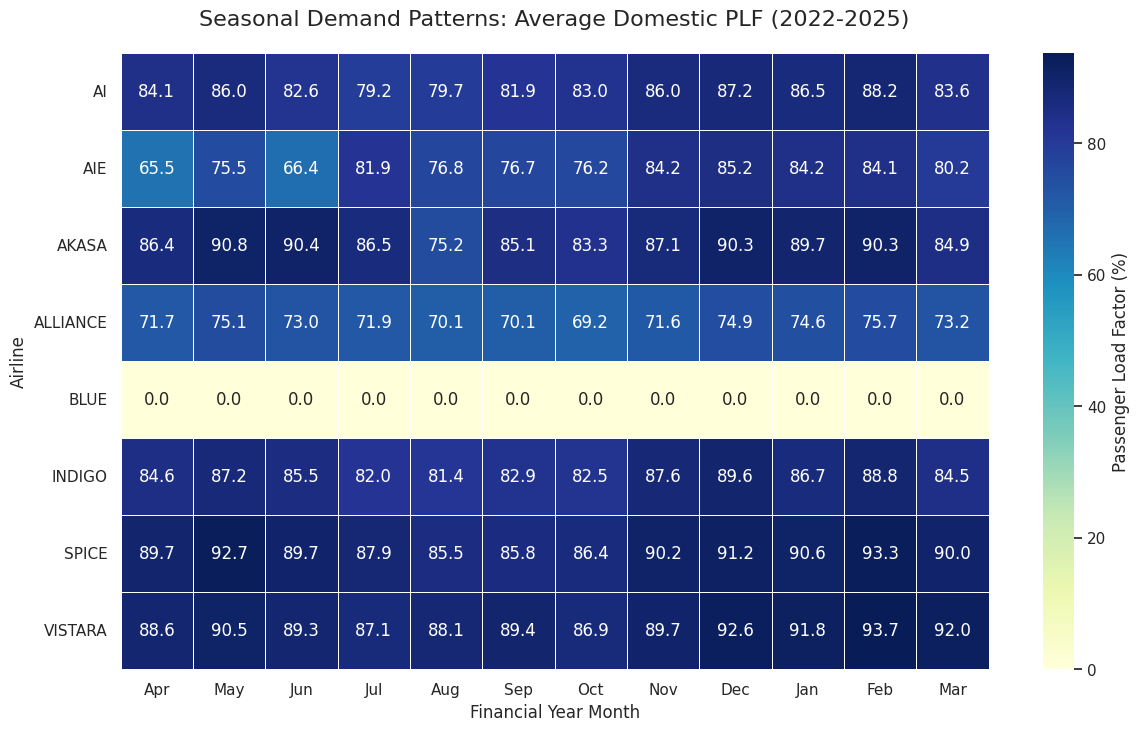

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# Create the heatmap
ax = sns.heatmap(
    plf_seasonal_domestic, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    linewidths=0.5,
    cbar_kws={'label': 'Passenger Load Factor (%)'}
)

# Labeling and Formatting
plt.title('Seasonal Demand Patterns: Average Domestic PLF (2022-2025)', fontsize=16, pad=20)
plt.xlabel('Financial Year Month', fontsize=12)
plt.ylabel('Airline', fontsize=12)

plt.yticks(rotation=0)

plt.show()

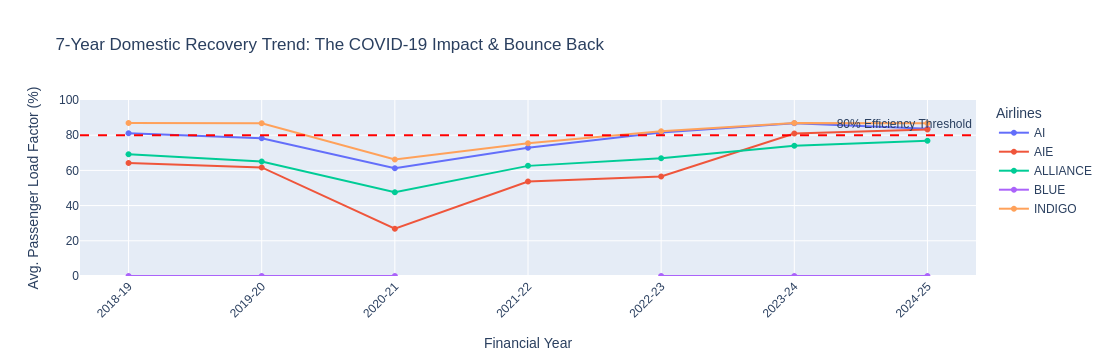

In [40]:
import plotly.express as px

fig = px.line(
    recovery_trend_refined, 
    x='Session', 
    y='PLF', 
    color='Airline',
    markers=True,
    title='7-Year Domestic Recovery Trend: The COVID-19 Impact & Bounce Back',
    labels={'PLF': 'Avg. Passenger Load Factor (%)', 'Session': 'Financial Year'},
    category_orders={"Session": ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]}
)

# Add a horizontal line for the industry "Healthy" benchmark (usually 80-85%)
fig.add_hline(y=80, line_dash="dash", line_color="red", annotation_text="80% Efficiency Threshold")

# Enhance layout
fig.update_layout(
    xaxis_tickangle=-45,
    legend_title_text='Airlines',
    hovermode='x unified',
    yaxis_range=[0, 100] # Keeps the scale consistent
)

fig.show()

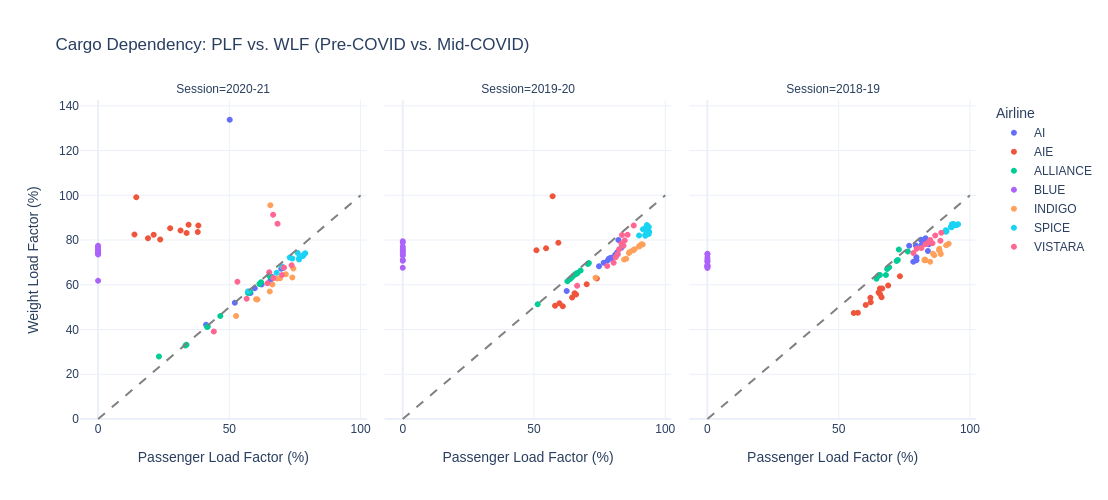

In [41]:
import numpy as np

# Filter for Domestic and handle potential NaNs
dataset_c_clean = dataset_c[dataset_c['Type'] == 1].dropna(subset=['PLF', 'WLF'])

# Create the Scatter Plot
fig = px.scatter(
    dataset_c_clean, 
    x='PLF', 
    y='WLF', 
    color='Airline',
    facet_col='Session', # Creates side-by-side charts for each year
    hover_data=['Date'],
    title='Cargo Dependency: PLF vs. WLF (Pre-COVID vs. Mid-COVID)',
    labels={'PLF': 'Passenger Load Factor (%)', 'WLF': 'Weight Load Factor (%)'},
    template='plotly_white'
)

# Add a Diagonal "Equality" Line (where PLF = WLF)
# Anything above this line is utilizing more weight capacity than seat capacity
for i in range(1, 4): # Apply to all 3 facet columns
    fig.add_shape(
        type='line', line=dict(dash='dash', color='gray'),
        x0=0, x1=100, y0=0, y1=100,
        row=1, col=i
    )

fig.update_layout(height=500)
fig.show()